## **Introduction**
We set up a script to analyze the experiments of notebook 1 for alpha=0.05

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
## Libraries
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import plotly.subplots as sp
import plotly.graph_objects as go
import seaborn as sns

import sys
import os

# Help function
#-------------------------------------------------------------------------------------------------------------------
# pooled standard error function
def pooled_se(series_se):
    n = len(series_se)
    if n <= 1:
        return np.nan
    return np.sqrt(np.sum(series_se**2 * (n - 1)) / (n * (n - 1)))

def compute_ics(df, lambda_weight=0.5, k=1, covgap_col='CovGap_mean', avgsize_col='AvgSize_mean',
                output_col='Ics', round_decimals=2):

    df[output_col] = (
        lambda_weight * df[covgap_col] +(1 - lambda_weight) * (df[avgsize_col] / k)
    ).round(round_decimals)
    return df



In [3]:

# PLOT SPLIT 2xN
#------------------------------------------


# Okabe–Ito palette (colorblind-safe)
#---------------------------------------------------
OKABE_ITO = {
    "blue":  "#0072B2",
    "orange":"#E69F00",
    "green": "#009E73",
    "yellow":"#F0E442",
    "red":   "#D55E00",
    "purple":"#CC79A7",
    "sky":   "#56B4E9",
    "black": "#000000"
}
COL_COVGAP  = OKABE_ITO["blue"]
COL_AVGSIZE = OKABE_ITO["green"]

# paper style
#-------------------------------------------------------------------------------------------
def set_paper_style(fontsize=9, tick_mult=0.95, title_mult=1.0):
    """
    Apply a compact, journal-ready Matplotlib style with light grid and bold axis labels.
    """
    plt.rcParams.update({
        "axes.edgecolor": "#BBBBBB",
        "axes.labelweight": "bold",
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize * title_mult,
        "xtick.labelsize": fontsize * tick_mult,
        "ytick.labelsize": fontsize * tick_mult,
        "grid.color": "#EAEAEA",
        "grid.linestyle": "-",
        "grid.linewidth": 0.6,
        "legend.frameon": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
    })

#Error bars with outline (for better print contrast)
#-----------------------------------------------------------------------------
def _draw_errorbar_with_outline(
    ax, x, y, yerr, color, marker="o", label=None, offset=0.0,
    outline_color="black", ms=4.0, elw_color=1.6, elw_outline=2.8,
    capsize=3.5, capthick=1.4, zorder=3
):
    """
    Draw the same errorbar twice:
      1) thick black outline underneath (improves visibility in print),
      2) colored errorbar on top (thinner).
    'yerr' can be 1D (symmetric) or [low, high] (asymmetric).
    """
    x_plot = np.asarray(x, dtype=float) + float(offset)

    # Outline (underneath)
    ax.errorbar(x_plot, y, yerr=yerr, fmt=marker,
                ms=ms, mfc="white", mec="black", mew=0.55,
                ecolor=outline_color, elinewidth=elw_outline,
                capsize=capsize, capthick=elw_outline,
                linestyle="", zorder=zorder-1, alpha=0.9)
    # Colored (on top)
    ln = ax.errorbar(x_plot, y, yerr=yerr, fmt=marker,
                     ms=ms, mfc="white", mec="black", mew=0.55,
                     ecolor=color, elinewidth=elw_color,
                     capsize=capsize, capthick=capthick,
                     linestyle="", zorder=zorder, label=label)
    return ln

# Utility: compute y-limits including error bars
#--------------------------------------------------------------------------------------------------
def _limits_from_errors(df, mean_col, err_col, scale=1.0, pad_frac=0.06, floor_zero=True):
    """
    Compute (ymin, ymax) from mean ± scale*err across the given DataFrame.
    Adds a fractional padding. Optionally floors the lower bound at zero.
    """
    y = np.asarray(df[mean_col], dtype=float)
    e = np.asarray(df[err_col], dtype=float)

    # Treat NaNs safely
    with np.errstate(invalid='ignore'):
        low  = y - scale * e
        high = y + scale * e

    ymin = np.nanmin(low)
    ymax = np.nanmax(high)

    # Handle degenerate case (all NaN or zero range)
    if not np.isfinite(ymin) or not np.isfinite(ymax):
        ymin, ymax = np.nanmin(y), np.nanmax(y)
    rng = max(ymax - ymin, 1e-9)
    pad = pad_frac * rng

    ymin_p = max(0.0, ymin - pad) if floor_zero else (ymin - pad)
    ymax_p = ymax + pad
    return (ymin_p, ymax_p)

# Main plotting function: split 2×N (no twinx)
#------------------------------------------------------------------------------
def plot_covgap_avgsize_split(
    summary_df: pd.DataFrame,
    covgap_y_column: str, covgap_yerr_column: str,
    avgsize_y_column: str, avgsize_yerr_column: str,
    model_f1_scores: dict, alpha: float,
    covgap_ylim=None, avgsize_ylim=None,
    save_path_pdf=None, save_path_png=None,

    # --- Compact layout parameters ---
    base_font: float = 7.5,      # base font size for axes and titles
    legend_font: float = 7.0,    # legend font size
    title_mult: float = 1.0,     # title size multiplier vs base_font
    tick_mult: float = 0.95,     # tick size multiplier vs base_font
    ms_cov: float = 1.6,         # marker size for CovGap
    ms_avg: float = 1.6,         # marker size for AvgSize
    capsize: float = 3.2,        # errorbar cap size
    capthick: float = 1.3,       # errorbar cap thickness (colored layer)
    elw_color: float = 1.5,      # colored errorbar line width
    elw_outline: float = 2.6,    # outline errorbar line width
    figsize_per_col: float = 2.4,# figure width per column (inches)
    height_total: float = 4.2,   # total figure height (inches)
    rotate_x: int = 0,           # rotation of x tick labels (degrees)
    fontsize_xticks: float = 5,  # x tick labels font size

    # --- Single centered xlabel "Method" across the figure ---
    central_xlabel: bool = True,
    xlabel_text: str = "Method",
    xlabel_fontsize: float | None = None,
    xlabel_y: float = 0.02,

    # --- NEW: y-limit control that includes error bars ---
    ylim_from_errors: bool = True,  # if True, derive y-limits from mean ± scale*err
    yerr_scale_cov: float = 1.0,    # set to 1.96 if your bars represent SE but you want CI95% bounds for ylim
    yerr_scale_avg: float = 1.0,    # same for AvgSize
    ylim_pad_frac: float = 0.06     # extra padding around min/max (fraction of range)
):
    """
    Create a 2×N panel (N = number of models):
      • Row 1: CovGap (with error bars)
      • Row 2: AvgSize (with error bars)
    Avoid twinx to maximize the readability of intervals (error bars).

    If 'ylim_from_errors' is True, compute global y-limits including error bars (mean ± scale*err)
    with a small padding to avoid clipped caps.
    """
    # Apply compact style
    set_paper_style(fontsize=base_font, tick_mult=tick_mult, title_mult=title_mult)

    models = list(pd.unique(summary_df["Model"]))
    n_models = len(models)
    if n_models == 0:
        raise ValueError("summary_df does not contain any 'Model'.")

    # Compute axis limits (prefer including error bars)
    if covgap_ylim is None:
        if ylim_from_errors:
            covgap_ylim = _limits_from_errors(
                summary_df, covgap_y_column, covgap_yerr_column,
                scale=yerr_scale_cov, pad_frac=ylim_pad_frac, floor_zero=True
            )
        else:
            cg_min = summary_df[covgap_y_column].min()
            cg_max = summary_df[covgap_y_column].max()
            cg_rng = cg_max - cg_min if cg_max > cg_min else (abs(cg_max) + 1e-9)
            covgap_ylim = (max(0, cg_min - 0.15*cg_rng), cg_max + 0.15*cg_rng)

    if avgsize_ylim is None:
        if ylim_from_errors:
            avgsize_ylim = _limits_from_errors(
                summary_df, avgsize_y_column, avgsize_yerr_column,
                scale=yerr_scale_avg, pad_frac=ylim_pad_frac, floor_zero=True
            )
        else:
            av_min = summary_df[avgsize_y_column].min()
            av_max = summary_df[avgsize_y_column].max()
            av_rng = av_max - av_min if av_max > av_min else (abs(av_max) + 1e-9)
            avgsize_ylim = (max(0, av_min - 0.15*av_rng), av_max + 0.15*av_rng)

    # Create a 2×N figure
    fig_width = max(figsize_per_col * n_models, 6.2)  # minimum width to avoid overcrowding
    fig, axs = plt.subplots(2, n_models, figsize=(fig_width, height_total), sharex=False)

    for j, model in enumerate(models):
        data_model = summary_df.loc[summary_df["Model"] == model].copy()
        methods = data_model["Method"].tolist()
        x_pos = np.arange(len(methods), dtype=float)

        # --- Row 1: CovGap ---
        ax_cg = axs[0, j] if n_models > 1 else axs[0]
        ax_cg.grid(True, axis="y")
        ax_cg.set_ylim(*covgap_ylim)

        y  = data_model[covgap_y_column].to_numpy()
        ye = data_model[covgap_yerr_column].to_numpy()
        ln1 = _draw_errorbar_with_outline(
            ax_cg, x_pos, y, yerr=ye, color=COL_COVGAP, marker="o", label="CovGap",
            ms=ms_cov, elw_color=elw_color, elw_outline=elw_outline,
            capsize=capsize, capthick=capthick, zorder=3
        )

        f1 = model_f1_scores.get(model, np.nan)
        title = f"{model}  (macro F1: {f1:.2f})" if isinstance(f1, (int, float)) and np.isfinite(f1) else f"{model}"
        ax_cg.set_title(title, pad=5, loc='center')

        ax_cg.set_xticks(x_pos)
        ax_cg.set_xticklabels(methods, rotation=rotate_x, fontsize=fontsize_xticks)
        if j == 0:
            ax_cg.set_ylabel("CovGap", color=COL_COVGAP)

        # --- Row 2: AvgSize ---
        ax_av = axs[1, j] if n_models > 1 else axs[1]
        ax_av.grid(True, axis="y")
        ax_av.set_ylim(*avgsize_ylim)

        y2  = data_model[avgsize_y_column].to_numpy()
        ye2 = data_model[avgsize_yerr_column].to_numpy()
        ln2 = _draw_errorbar_with_outline(
            ax_av, x_pos, y2, yerr=ye2, color=COL_AVGSIZE, marker="s", label="AvgSize",
            ms=ms_avg, elw_color=elw_color, elw_outline=elw_outline,
            capsize=capsize, capthick=capthick, zorder=3
        )

        ax_av.set_xticks(x_pos)
        ax_av.set_xticklabels(methods, rotation=rotate_x, fontsize=fontsize_xticks)

        # Central xlabel will be handled at the figure level
        if j == 0:
            ax_av.set_ylabel("AvgSize", color=COL_AVGSIZE)

    # --- Legend (single, centered, with colored text) ---
    proxy_cov = Line2D([0], [0], color=COL_COVGAP, marker='o', linestyle='',
                       markerfacecolor='white', markeredgecolor='black', markersize=ms_cov+1, label="CovGap")
    proxy_avg = Line2D([0], [0], color=COL_AVGSIZE, marker='s', linestyle='',
                       markerfacecolor='white', markeredgecolor='black', markersize=ms_avg+1, label="AvgSize")
    alpha_text = rf"$\alpha$ = {alpha:.2f}"
    dummy = Line2D([], [], linestyle='', label=alpha_text)

    leg = fig.legend(
        [proxy_cov, proxy_avg, dummy],
        ["CovGap", "AvgSize", alpha_text],
        loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02),
        fontsize=legend_font
    )

    # Color legend text to match the series colors
    legend_colors = [COL_COVGAP, COL_AVGSIZE, "#333333"]  # alpha in neutral gray
    for txt, col in zip(leg.get_texts(), legend_colors):
        txt.set_color(col)

    # Leave extra bottom margin for the central xlabel
    plt.tight_layout(rect=[0, 0.06 if central_xlabel else 0, 1, 0.95])

    # Single centered xlabel across the figure
    if central_xlabel:
        fs = xlabel_fontsize if xlabel_fontsize is not None else base_font
        if hasattr(fig, "supxlabel"):
            fig.supxlabel(xlabel_text, fontsize=fs, y=xlabel_y)
        else:
            fig.text(0.5, xlabel_y, xlabel_text, ha='center', va='bottom', fontsize=fs)

    if save_path_pdf:
        os.makedirs(os.path.dirname(save_path_pdf), exist_ok=True)
        fig.savefig(save_path_pdf, bbox_inches="tight")
    if save_path_png:
        os.makedirs(os.path.dirname(save_path_png), exist_ok=True)
        fig.savefig(save_path_png, dpi=600, bbox_inches="tight")

## **Analysis for simulations of Scenarios 1-4 with α=0.05**

In [4]:
path = '/content/gdrive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/Simulations/results/result_10.2025/'
# Experiments for alpha=0.1
file1= 'summary_005_part1.csv'
file2= 'summary_005_part2.csv'
#file4= 'summary_005_part22.csv'
file3= 'summary_005_part3.csv'


df1 = pd.read_csv(path+file1)
df2 = pd.read_csv(path+file2)
df3 = pd.read_csv(path+file3)
#df4 = pd.read_csv(path+file4)

#df = pd.concat([df1, df2, df4, df3], ignore_index=True)
df = pd.concat([df1, df2, df3], ignore_index=True)

num_expts = df['Experiment'].nunique()
print(f"Check: number of experiments {num_expts}")
print("shape:", df.shape)

Check: number of experiments 39
shape: (468, 11)


In [5]:
df['Experiment'].unique()

array(['s1_1', 's1_2', 's1_3', 's1_4', 's1_5', 's1_6', 's1_7', 's1_8',
       's1_9', 's1_10', 's1_11', 's1_12', 's1_13', 's1_14', 's2_1',
       's2_2', 's2_3', 's2_4', 's2_5', 's2_6', 's2_7', 's2_8', 's3_1',
       's3_2', 's3_3', 's3_4', 's3_5', 's3_6', 's3_7', 's3_8', 's3_9',
       's3_10', 's4_1', 's4_2', 's4_3', 's4_4', 's4_5', 's4_6', 's4_7'],
      dtype=object)

We generate a script that:


*   Groups the data by Scenario, Model, and Method
*   Computes the mean of: F1 Score, CovGap_mean, and AvgSize_mean
*   Computes the pooled standard error for CovGap_se and AvgSize_se



In [6]:
# group by Scenario, Model, Method
grouped = df.groupby(['Scenario', 'Model', 'Method'])

# Calcola medie e pooled standard error, approssimando alla terza cifra
summary = grouped.agg({
    'F1 Score': lambda x: round(x.mean(), 2),
    'CovGap_mean': lambda x: round(x.mean(), 2),
    'CovGap_se': pooled_se,
    'AvgSize_mean': lambda x: round(x.mean(), 2),
    'AvgSize_se': pooled_se
}).reset_index()

# ordered by Method
method_order = ['Standard', 'Classwise', 'Clustered', 'Augmented']
summary['Method'] = pd.Categorical(summary['Method'], categories=method_order, ordered=True)

# ordered by Model
model_order = ['Random Forest', 'XGBoost', 'MLP Neural Net']
summary['Model'] = pd.Categorical(summary['Model'], categories=model_order, ordered=True)

# Ordina il DataFrame
summary_sorted = summary.sort_values(by=['Scenario', 'Model', 'Method']).reset_index(drop=True)

summary_sorted.to_csv('summary_table_alpha_01.csv', index=False)
summary_sorted.head(10)

,Scenario,Model,Method,F1 Score,CovGap_mean,CovGap_se,AvgSize_mean,AvgSize_se
0,s1,Random Forest,Standard,0.63,0.07,0.006698,2.60,0.090882
1,s1,Random Forest,Classwise,0.63,0.03,0.003928,4.14,0.113254
2,s1,Random Forest,Clustered,0.63,0.07,0.006745,2.61,0.093684
3,s1,Random Forest,Augmented,0.63,0.03,0.004036,3.07,0.031855
4,s1,XGBoost,Standard,0.73,0.06,0.006464,1.91,0.061376
5,s1,XGBoost,Classwise,0.73,0.03,0.003798,3.33,0.104783
6,s1,XGBoost,Clustered,0.73,0.05,0.006595,1.93,0.064510
7,s1,XGBoost,Augmented,0.73,0.04,0.004472,2.03,0.022160
8,s1,MLP Neural Net,Standard,0.79,0.04,0.005244,1.58,0.028212
9,s1,MLP Neural Net,Classwise,0.79,0.03,0.003770,2.90,0.048694


In [7]:
summary_sorted[summary_sorted['Scenario'] != 's4'].reset_index(drop=True)

,Scenario,Model,Method,F1 Score,CovGap_mean,CovGap_se,AvgSize_mean,AvgSize_se
0,s1,Random Forest,Standard,0.63,0.07,0.006698,2.60,0.090882
1,s1,Random Forest,Classwise,0.63,0.03,0.003928,4.14,0.113254
2,s1,Random Forest,Clustered,0.63,0.07,0.006745,2.61,0.093684
3,s1,Random Forest,Augmented,0.63,0.03,0.004036,3.07,0.031855
4,s1,XGBoost,Standard,0.73,0.06,0.006464,1.91,0.061376
5,s1,XGBoost,Classwise,0.73,0.03,0.003798,3.33,0.104783
6,s1,XGBoost,Clustered,0.73,0.05,0.006595,1.93,0.064510
7,s1,XGBoost,Augmented,0.73,0.04,0.004472,2.03,0.022160
8,s1,MLP Neural Net,Standard,0.79,0.04,0.005244,1.58,0.028212
9,s1,MLP Neural Net,Classwise,0.79,0.03,0.003770,2.90,0.048694


## Interval plots for scenarios 1-4

/tmp/ipython-input-2313854791.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_f1_scores = summary_i.groupby('Model')['F1 Score'].mean().round(3).to_dict()
/tmp/ipython-input-2313854791.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_f1_scores = summary_i.groupby('Model')['F1 Score'].mean().round(3).to_dict()
/tmp/ipython-input-2313854791.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_f1_sco

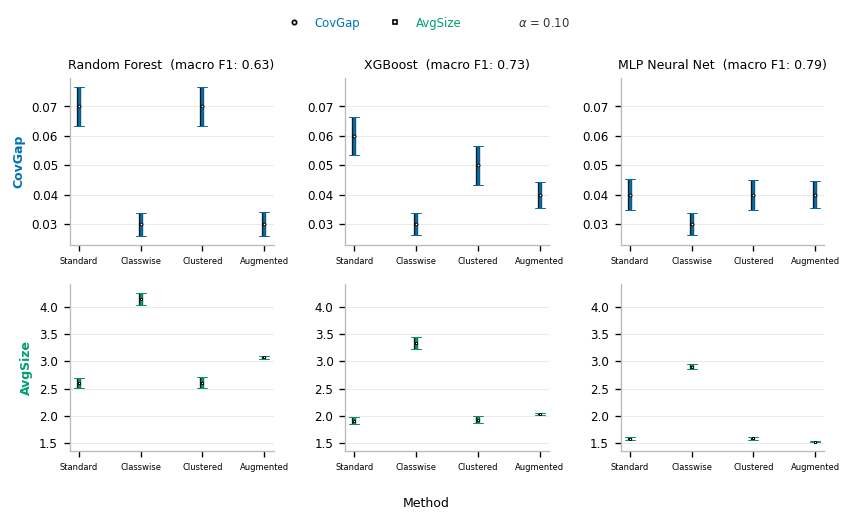

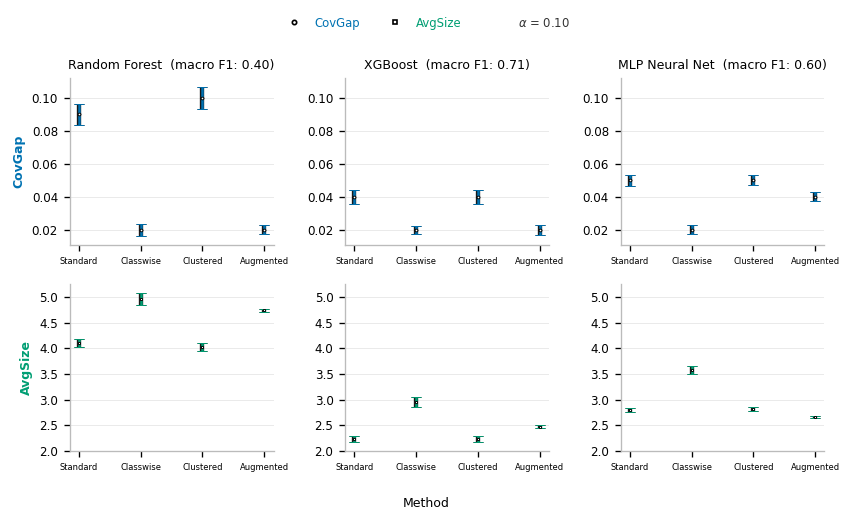

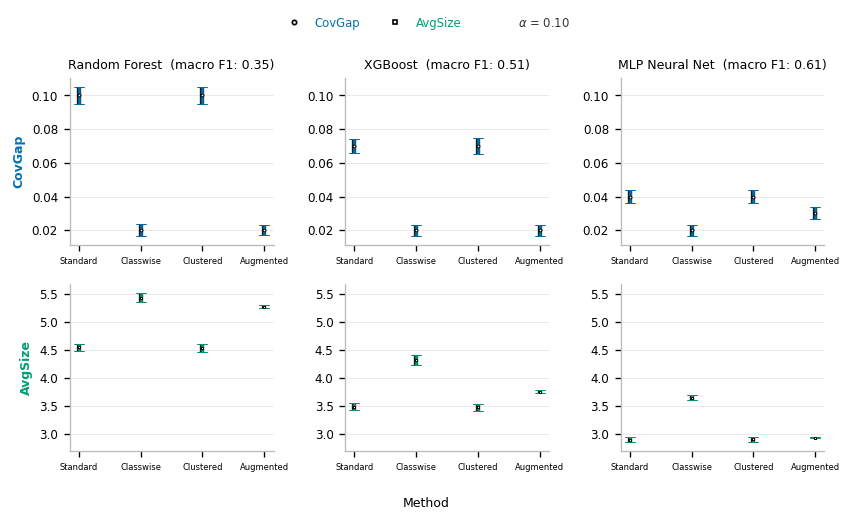

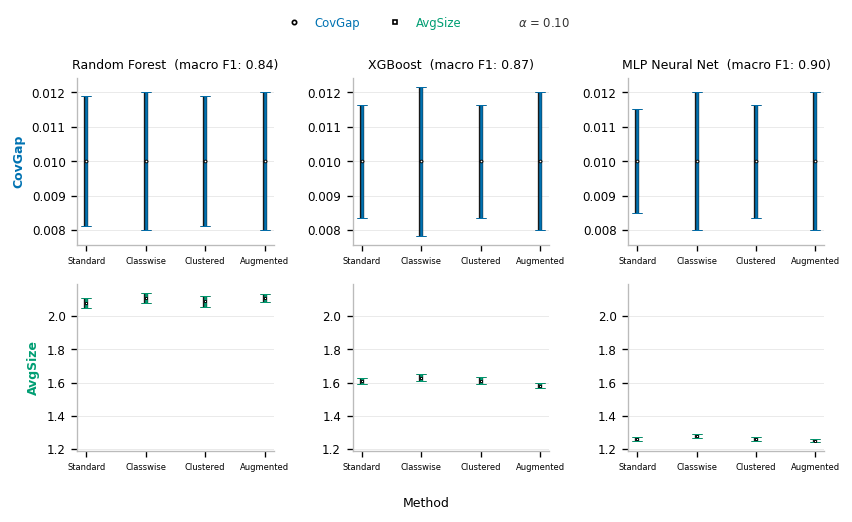

In [9]:
for i in range(1, 5):
    scenario = f's{i}'
    plot_name = f'scenario_{i}_alpha_005.pdf'

    # Filtra i dati per lo scenario corrente
    summary_i = summary_sorted[summary_sorted['Scenario'] == scenario].reset_index(drop=True)

    # Calcola F1 Score medio per ogni modello nello scenario corrente
    model_f1_scores = summary_i.groupby('Model')['F1 Score'].mean().round(3).to_dict()

    # Genera il plot
    plot_covgap_avgsize_split(
    summary_i,
    covgap_y_column='CovGap_mean', covgap_yerr_column='CovGap_se',
    avgsize_y_column='AvgSize_mean', avgsize_yerr_column='AvgSize_se',
    model_f1_scores=model_f1_scores, alpha=0.1,
    save_path_pdf=path+plot_name,
    save_path_png=None)

## Analysis of scenario 4

In [10]:
summary4 = summary_sorted[summary_sorted['Scenario'] == 's4'].reset_index(drop=True)
compute_ics(summary4)

,Scenario,Model,Method,F1 Score,CovGap_mean,CovGap_se,AvgSize_mean,AvgSize_se,Ics
0,s4,Random Forest,Standard,0.84,0.01,0.001890,2.08,0.031069,1.04
1,s4,Random Forest,Classwise,0.84,0.01,0.002000,2.11,0.031630,1.06
2,s4,Random Forest,Clustered,0.84,0.01,0.001890,2.09,0.033078,1.05
3,s4,Random Forest,Augmented,0.84,0.01,0.002000,2.11,0.025898,1.06
4,s4,XGBoost,Standard,0.87,0.01,0.001648,1.61,0.019716,0.81
5,s4,XGBoost,Classwise,0.87,0.01,0.002171,1.63,0.020315,0.82
6,s4,XGBoost,Clustered,0.87,0.01,0.001648,1.61,0.020764,0.81
7,s4,XGBoost,Augmented,0.87,0.01,0.002000,1.58,0.015250,0.80
8,s4,MLP Neural Net,Standard,0.90,0.01,0.001512,1.26,0.010461,0.64
9,s4,MLP Neural Net,Classwise,0.90,0.01,0.002000,1.28,0.012536,0.64


## Analysis of scenario 1,2,3

In [11]:
summary_123 = summary_sorted[summary_sorted['Scenario'] != 's4'].reset_index(drop=True)

# group by Scenario, Model, Method
grouped = summary_123.groupby(['Model', 'Method'])

# Calcola medie e pooled standard error, approssimando alla terza cifra
summary_123 = grouped.agg({
    'F1 Score': lambda x: round(x.mean(), 2),
    'CovGap_mean': lambda x: round(x.mean(), 2),
    'CovGap_se': pooled_se,
    'AvgSize_mean': lambda x: round(x.mean(), 2),
    'AvgSize_se': pooled_se
}).reset_index()

compute_ics(summary_123)

/tmp/ipython-input-2158260376.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = summary_123.groupby(['Model', 'Method'])


,Model,Method,F1 Score,CovGap_mean,CovGap_se,AvgSize_mean,AvgSize_se,Ics
0,Random Forest,Standard,0.46,0.09,0.006212,3.75,0.077291,1.92
1,Random Forest,Classwise,0.46,0.02,0.003752,4.85,0.108980,2.43
2,Random Forest,Clustered,0.46,0.09,0.006335,3.73,0.079960,1.91
3,Random Forest,Augmented,0.46,0.02,0.003315,4.36,0.032460,2.19
4,XGBoost,Standard,0.65,0.06,0.005121,2.54,0.061523,1.30
5,XGBoost,Classwise,0.65,0.02,0.003216,3.54,0.096801,1.78
6,XGBoost,Clustered,0.65,0.05,0.005254,2.55,0.064227,1.30
7,XGBoost,Augmented,0.65,0.03,0.003612,2.75,0.024412,1.39
8,MLP Neural Net,Standard,0.67,0.04,0.004205,2.43,0.037462,1.24
9,MLP Neural Net,Classwise,0.67,0.02,0.003250,3.38,0.059404,1.70


In [12]:
summary_123 = summary_sorted[summary_sorted['Scenario'] != 's4'].reset_index(drop=True)

# group by Scenario, Model, Method
grouped = summary_123.groupby(['Method'])

# Calcola medie e pooled standard error, approssimando alla terza cifra
summary_123 = grouped.agg({
    'F1 Score': lambda x: round(x.mean(), 2),
    'CovGap_mean': lambda x: round(x.mean(), 2),
    'CovGap_se': pooled_se,
    'AvgSize_mean': lambda x: round(x.mean(), 2),
    'AvgSize_se': pooled_se
}).reset_index()

compute_ics(summary_123)

/tmp/ipython-input-214740021.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = summary_123.groupby(['Method'])


,Method,F1 Score,CovGap_mean,CovGap_se,AvgSize_mean,AvgSize_se,Ics
0,Standard,0.59,0.06,0.005244,2.91,0.060998,1.48
1,Classwise,0.59,0.02,0.003415,3.92,0.090877,1.97
2,Clustered,0.59,0.06,0.005330,2.90,0.063043,1.48
3,Augmented,0.59,0.03,0.003539,3.16,0.024810,1.60
